<a href="https://colab.research.google.com/github/BubuDavid/ml-journey-workshop/blob/main/notebooks/word2vec_embeddings_workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📐 Word Embeddings: Aritmética con Palabras

En este notebook vamos a explorar **word embeddings** de forma práctica. La idea central es que las palabras se pueden representar como vectores en un espacio de alta dimensión, y que ese espacio tiene **estructura geométrica significativa**: palabras similares están cerca, y las relaciones semánticas se codifican como direcciones.

Usaremos **Word2Vec** (Google News, 300 dimensiones), uno de los modelos clásicos de embeddings. Cada palabra tiene un único vector fijo — a diferencia de modelos como GPT-2, donde el vector de una palabra cambia según su contexto.

### Prerequisitos
- Vectores, producto punto, norma.
- Noción intuitiva de similitud coseno.

### ¿Qué es un embedding?
Es una función que asigna a cada palabra un vector en $\mathbb{R}^{d}$ (en nuestro caso, $d = 300$). Si el embedding es bueno:

$$\text{sim}(\vec{v}_{\text{dog}}, \vec{v}_{\text{cat}}) > \text{sim}(\vec{v}_{\text{dog}}, \vec{v}_{\text{algebra}})$$

donde $\text{sim}$ es la **similitud coseno**:

$$\text{sim}(\vec{a}, \vec{b}) = \frac{\vec{a} \cdot \vec{b}}{\|\vec{a}\| \, \|\vec{b}\|}$$

---
## 1. Setup

Cargamos Word2Vec preentrenado en ~100 mil millones de palabras de Google News. Son ~3 millones de palabras, cada una representada por un vector de 300 dimensiones. La descarga toma 1-2 minutos.

In [19]:
!pip install gensim -q

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import gensim.downloader as api

print("Descargando Word2Vec (esto toma 1-2 min)...")
wv = api.load("word2vec-google-news-300")
print(f"✅ Modelo cargado")
print(f"   Vocabulario: {len(wv):,} palabras")
print(f"   Dimensiones: {wv.vector_size}")

Descargando Word2Vec (esto toma 1-2 min)...
✅ Modelo cargado
   Vocabulario: 3,000,000 palabras
   Dimensiones: 300


---
## 2. Exploración básica: ¿qué es un embedding?

Cada palabra del vocabulario tiene asociado un vector de 300 números reales. Veamos cómo se ve uno.

In [21]:
# --- CONFIGURABLE ---
WORD = "king"
# --------------------

vec = wv[WORD]

print(f"Palabra: '{WORD}'")
print(f"Tipo: {type(vec)}")
print(f"Shape: {vec.shape}")
print(f"Norma: {np.linalg.norm(vec):.4f}")
print(f"\nPrimeros 10 valores:")
print(vec[:10])

Palabra: 'king'
Tipo: <class 'numpy.ndarray'>
Shape: (300,)
Norma: 2.9023

Primeros 10 valores:
[ 0.12597656  0.02978516  0.00860596  0.13964844 -0.02563477 -0.03613281
  0.11181641 -0.19824219  0.05126953  0.36328125]


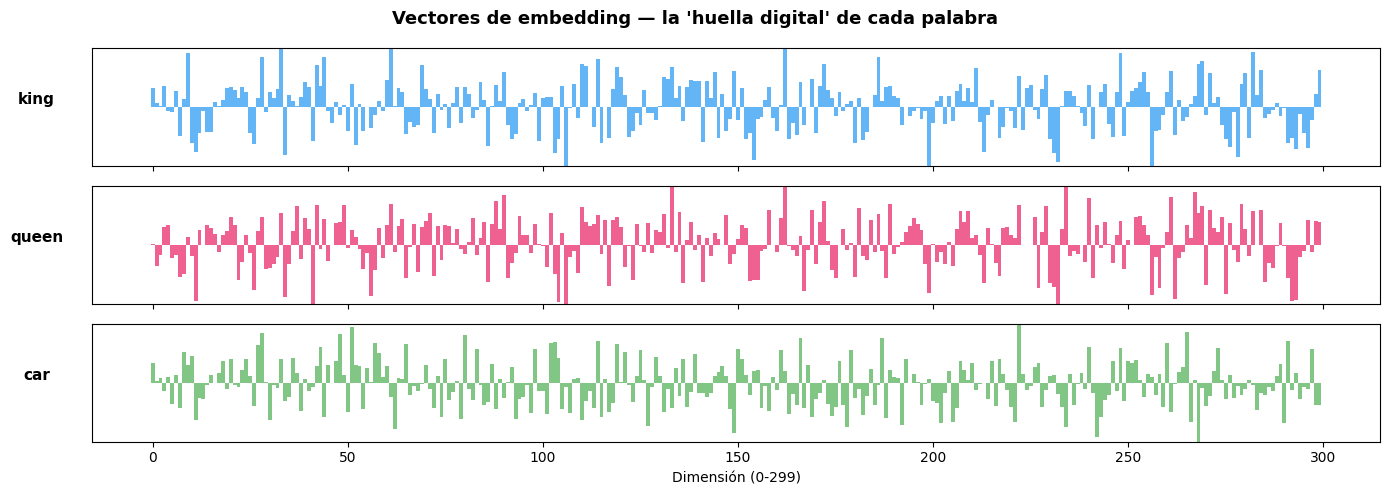

In [22]:
# Visualizar el vector completo como una "huella digital" de la palabra
fig, axes = plt.subplots(3, 1, figsize=(14, 5), sharex=True)

words_to_show = ["king", "queen", "car"]
colors = ["#2196F3", "#E91E63", "#4CAF50"]

for ax, word, color in zip(axes, words_to_show, colors):
    ax.bar(range(300), wv[word], width=1.0, color=color, alpha=0.7)
    ax.set_ylabel(word, fontsize=11, fontweight="bold", rotation=0, labelpad=40)
    ax.set_ylim(-0.4, 0.4)
    ax.set_yticks([])

axes[-1].set_xlabel("Dimensión (0-299)")
fig.suptitle("Vectores de embedding — la 'huella digital' de cada palabra", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

☝️ Cada barra es una dimensión del vector. Tal vez **king** y **queen** comparten cierta estructura? (ambas son realeza) mientras que **car** se ve diferente. Esos 300 números codifican el significado de la palabra — aprendido automáticamente de los patrones de co-ocurrencia en texto.

---
## 3. Similitud entre palabras

La similitud coseno mide el ángulo entre dos vectores. Valores cercanos a 1 significan que las palabras están en la misma "dirección" semántica; cercanos a 0 significan que no tienen relación; y negativos indicarían cierta oposición.

In [23]:
# Similitud entre pares de palabras
pairs = [
    ("dog", "cat"),
    ("dog", "puppy"),
    ("dog", "car"),
    ("dog", "algebra"),
    ("king", "queen"),
    ("king", "throne"),
    ("happy", "sad"),
    ("good", "evil"),
    ("France", "Paris"),
    ("Japan", "Tokyo"),
]

print(f"{'Palabra A':<12} {'Palabra B':<12} {'Similitud':>10}")
print("—" * 36)
for w1, w2 in pairs:
    sim = wv.similarity(w1, w2)
    bar = "█" * int(abs(sim) * 20)
    print(f"{w1:<12} {w2:<12} {sim:>8.4f}  {bar}")

Palabra A    Palabra B     Similitud
————————————————————————————————————
dog          cat            0.7609  ███████████████
dog          puppy          0.8106  ████████████████
dog          car            0.3100  ██████
dog          algebra        0.0185  
king         queen          0.6511  █████████████
king         throne         0.5422  ██████████
happy        sad            0.5355  ██████████
good         evil           0.2060  ████
France       Paris          0.6335  ████████████
Japan        Tokyo          0.7002  ██████████████


In [24]:
# Las 10 palabras más similares a una dada
# --- CONFIGURABLE ---
QUERY_WORD = "physics"
# --------------------

print(f"Top 10 palabras más cercanas a '{QUERY_WORD}':\n")
for word, score in wv.most_similar(QUERY_WORD, topn=10):
    bar = "█" * int(score * 20)
    print(f"  {word:<25} {score:.4f}  {bar}")

Top 10 palabras más cercanas a 'physics':

  quantum_mechanics         0.6977  █████████████
  Physics                   0.6907  █████████████
  quantum_physics           0.6846  █████████████
  astrophysics              0.6702  █████████████
  particle_physics          0.6592  █████████████
  thermodynamics            0.6547  █████████████
  Chu_Nobel_laureate        0.6443  ████████████
  theoretical_physics       0.6382  ████████████
  physicist                 0.6186  ████████████
  fluid_dynamics            0.6176  ████████████


In [25]:
# Encontrar el "intruso" — la palabra que no pertenece al grupo
groups = [
    ["breakfast", "lunch", "dinner", "laptop"],
    ["cat", "dog", "fish", "airplane"],
    ["red", "green", "blue", "president"],
    ["Einstein", "Newton", "Feynman", "Beyonce"],
]

print("¿Quién no pertenece al grupo?\n")
for group in groups:
    outlier = wv.doesnt_match(group)
    print(f"  {group} → intruso: {outlier}")

¿Quién no pertenece al grupo?

  ['breakfast', 'lunch', 'dinner', 'laptop'] → intruso: laptop
  ['cat', 'dog', 'fish', 'airplane'] → intruso: airplane
  ['red', 'green', 'blue', 'president'] → intruso: president
  ['Einstein', 'Newton', 'Feynman', 'Beyonce'] → intruso: Beyonce


☝️ El modelo identifica al intruso sin tener "definiciones" de las palabras — solo usando la geometría del espacio vectorial. Las palabras de un mismo campo semántico forman clusters, y la palabra lejana al centroide del grupo es el intruso.

---
## 4. Aritmética vectorial: el truco mágico

La propiedad más sorprendente de Word2Vec es que las **relaciones semánticas se codifican como vectores de desplazamiento**. Si restamos $\vec{v}_{\text{man}}$ de $\vec{v}_{\text{king}}$, obtenemos un vector que captura la "dirección de la realeza". Si sumamos esa dirección a $\vec{v}_{\text{woman}}$:

$$\vec{v}_{\text{king}} - \vec{v}_{\text{man}} + \vec{v}_{\text{woman}} \approx \vec{v}_{\text{queen}}$$

Esto funciona porque el entrenamiento aprendió a codificar relaciones semánticas como **direcciones consistentes** en el espacio.

In [26]:
def analogy(wv, a, b, c, topn=5):
    """
    Resuelve la analogía: a es a b como c es a ???
    Operación: vec(b) - vec(a) + vec(c) ≈ vec(???)

    Ejemplo: king es a man como queen es a woman
             analogy('man', 'king', 'woman') → queen
    """
    result = wv.most_similar(positive=[b, c], negative=[a], topn=topn)

    print(f"  {a} → {b}  como  {c} → ???")
    print(f"  Operación: vec({b}) - vec({a}) + vec({c})\n")
    for word, score in result:
        bar = "█" * int(score * 20)
        print(f"    {word:<20} {score:.4f}  {bar}")
    print()

In [27]:
print("=" * 50)
print("ANALOGÍAS CLÁSICAS")
print("=" * 50)
print()

# Género
print("— Género —")
analogy(wv, "man", "king", "woman")
analogy(wv, "man", "brother", "woman")

# Países y capitales
print("— País → Capital —")
analogy(wv, "France", "Paris", "Japan")
analogy(wv, "France", "Paris", "Mexico")

# Tiempos verbales
print("— Conjugación verbal —")
analogy(wv, "walk", "walked", "swim")
analogy(wv, "go", "went", "eat")

# Comparativos
print("— Comparativos —")
analogy(wv, "good", "better", "bad")
analogy(wv, "big", "bigger", "small")

ANALOGÍAS CLÁSICAS

— Género —
  man → king  como  woman → ???
  Operación: vec(king) - vec(man) + vec(woman)

    queen                0.7118  ██████████████
    monarch              0.6190  ████████████
    princess             0.5902  ███████████
    crown_prince         0.5499  ██████████
    prince               0.5377  ██████████

  man → brother  como  woman → ???
  Operación: vec(brother) - vec(man) + vec(woman)

    sister               0.8103  ████████████████
    daughter             0.7647  ███████████████
    mother               0.7524  ███████████████
    son                  0.7238  ██████████████
    niece                0.7216  ██████████████

— País → Capital —
  France → Paris  como  Japan → ???
  Operación: vec(Paris) - vec(France) + vec(Japan)

    Tokyo                0.8143  ████████████████
    Toyko                0.6597  █████████████
    Osaka                0.6351  ████████████
    Nagoya               0.6259  ████████████
    Seoul                0.6055  █

☝️ Observa cómo la aritmética vectorial captura relaciones semánticas **sin que nadie le haya enseñado gramática, geografía o jerarquías**. El modelo las aprendió de los patrones estadísticos del texto.

Geométricamente, el vector $\vec{v}_{\text{king}} - \vec{v}_{\text{man}}$ apunta en una dirección que codifica "realeza". Esa misma dirección aplicada desde $\vec{v}_{\text{woman}}$ nos lleva a $\vec{v}_{\text{queen}}$. Es un **paralelogramo** en 300 dimensiones.

---
## 5. Visualización en 2D con PCA

Tenemos vectores en $\mathbb{R}^{300}$ — imposible visualizarlos directamente. Usamos **PCA (Análisis de Componentes Principales)** para proyectar a 2D, conservando la mayor varianza posible.

Esto es una proyección lineal: se pierden relaciones, pero la estructura gruesa de clusters suele sobrevivir.

In [28]:
def plot_word_clusters(wv, word_groups, title="Word Embeddings en 2D (PCA)"):
    """
    Visualiza grupos de palabras en 2D usando PCA.

    Args:
        wv: modelo Word2Vec
        word_groups: dict {nombre_grupo: [lista de palabras]}
        title: título del plot
    """
    all_words = []
    group_labels = []
    for group_name, words in word_groups.items():
        for w in words:
            if w in wv:
                all_words.append(w)
                group_labels.append(group_name)

    vectors = np.array([wv[w] for w in all_words])

    pca = PCA(n_components=2)
    coords = pca.fit_transform(vectors)

    fig, ax = plt.subplots(figsize=(12, 8))
    colors = plt.cm.Set1(np.linspace(0, 1, len(word_groups)))
    color_map = {name: colors[i] for i, name in enumerate(word_groups.keys())}

    for i, (word, group) in enumerate(zip(all_words, group_labels)):
        ax.scatter(coords[i, 0], coords[i, 1], c=[color_map[group]], s=100, zorder=2)
        ax.annotate(
            word, (coords[i, 0], coords[i, 1]),
            textcoords="offset points", xytext=(5, 5),
            fontsize=9, fontweight="bold"
        )

    # Leyenda
    for group_name, color in color_map.items():
        ax.scatter([], [], c=[color], s=100, label=group_name)
    ax.legend(fontsize=10, loc="best")

    var_explained = pca.explained_variance_ratio_
    ax.set_xlabel(f"PC1 ({var_explained[0]:.1%} varianza)", fontsize=11)
    ax.set_ylabel(f"PC2 ({var_explained[1]:.1%} varianza)", fontsize=11)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return pca

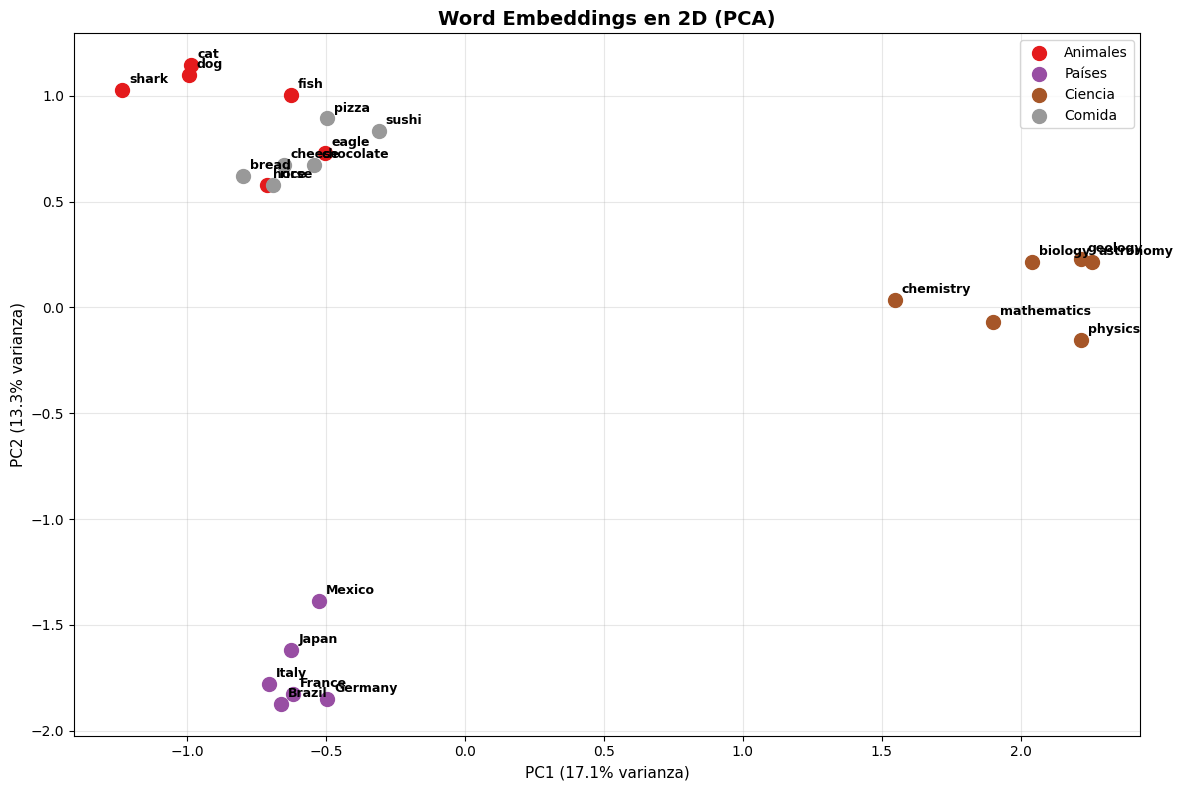

PCA(n_components=2)

In [29]:
# --- CONFIGURABLE ---
word_groups = {
    "Animales": ["dog", "cat", "horse", "fish", "eagle", "shark"],
    "Países": ["France", "Japan", "Mexico", "Germany", "Brazil", "Italy"],
    "Ciencia": ["physics", "chemistry", "biology", "mathematics", "astronomy", "geology"],
    "Comida": ["pizza", "sushi", "bread", "rice", "cheese", "chocolate"],
}
# --------------------

plot_word_clusters(wv, word_groups)

☝️ Aunque estamos comprimiendo 300 dimensiones a 2 (perdemos mucha información), los **clusters semánticos se conservan**: animales con animales, países con países, etc. PCA encuentra las dos direcciones de mayor varianza — piensen en ello como la "mejor vista posible" de una nube de puntos en alta dimensión.

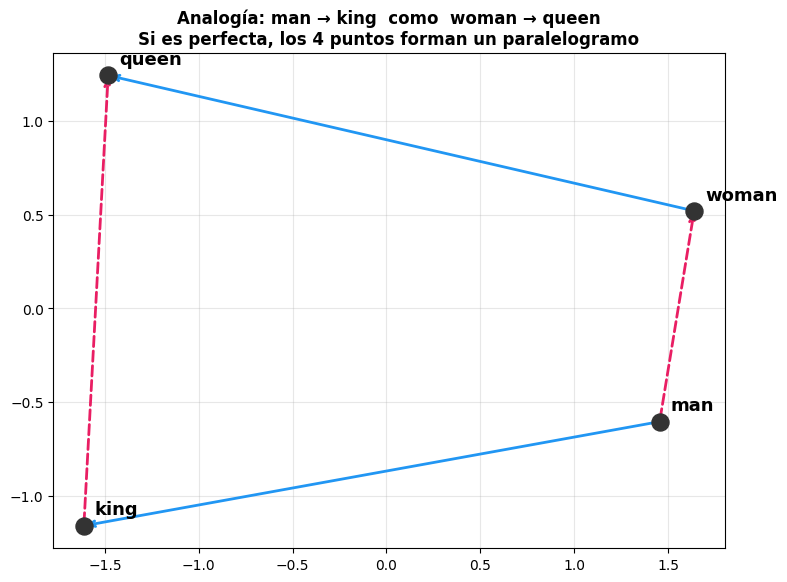

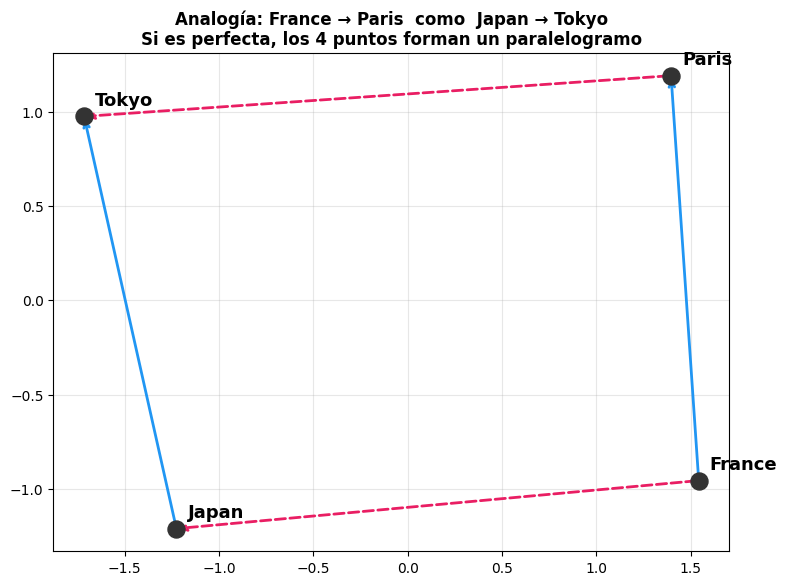

In [30]:
# Visualización de una analogía como paralelogramo
def plot_analogy(wv, a, b, c, d):
    """
    Visualiza la analogía a:b :: c:d como un paralelogramo en 2D.
    Si la analogía es perfecta, los 4 puntos forman un paralelogramo.
    """
    words = [a, b, c, d]
    vectors = np.array([wv[w] for w in words])

    pca = PCA(n_components=2)
    coords = pca.fit_transform(vectors)

    fig, ax = plt.subplots(figsize=(8, 6))

    # Dibujar las flechas de la analogía
    # a → b (la relación)
    ax.annotate("", xy=coords[1], xytext=coords[0],
                arrowprops=dict(arrowstyle="->", color="#2196F3", lw=2))
    # c → d (la misma relación aplicada)
    ax.annotate("", xy=coords[3], xytext=coords[2],
                arrowprops=dict(arrowstyle="->", color="#2196F3", lw=2))
    # a → c (el otro eje)
    ax.annotate("", xy=coords[2], xytext=coords[0],
                arrowprops=dict(arrowstyle="->", color="#E91E63", lw=2, linestyle="dashed"))
    # b → d (el otro eje)
    ax.annotate("", xy=coords[3], xytext=coords[1],
                arrowprops=dict(arrowstyle="->", color="#E91E63", lw=2, linestyle="dashed"))

    # Puntos y labels
    for i, word in enumerate(words):
        ax.scatter(coords[i, 0], coords[i, 1], s=150, zorder=3, color="#333")
        ax.annotate(
            word, (coords[i, 0], coords[i, 1]),
            textcoords="offset points", xytext=(8, 8),
            fontsize=13, fontweight="bold"
        )

    ax.set_title(
        f"Analogía: {a} → {b}  como  {c} → {d}\n"
        f"Si es perfecta, los 4 puntos forman un paralelogramo",
        fontsize=12, fontweight="bold"
    )
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

plot_analogy(wv, "man", "king", "woman", "queen")
plot_analogy(wv, "France", "Paris", "Japan", "Tokyo")

☝️ Si la analogía fuera perfecta, los 4 puntos formarían un paralelogramo exacto en 300D. En la proyección 2D se distorsiona un poco, pero la estructura se conserva. Las flechas azules representan la "relación" (hombre→rey, mujer→reina) y las flechas rosas el "otro eje" del paralelogramo.

---
## 6. Playground de analogías

Ahora experimenta tú. Modifica la celda de abajo con tus propias analogías. Algunas ideas para probar:

- `Spain → Madrid` como `Egypt → ???`
- `doctor → hospital` como `teacher → ???`
- `hot → cold` como `up → ???`
- `piano → music` como `brush → ???`

In [31]:
# --- PLAYGROUND ---
# Modifica estas analogías y ejecuta la celda

my_analogies = [
    # (a, b, c)  →  a es a b como c es a ???
    ("Spain", "Madrid", "Egypt"),
    ("doctor", "hospital", "teacher"),
    ("hot", "cold", "up"),
    ("piano", "music", "brush"),
]

print("=" * 50)
print("TUS ANALOGÍAS")
print("=" * 50)
print()

for a, b, c in my_analogies:
    analogy(wv, a, b, c, topn=3)

TUS ANALOGÍAS

  Spain → Madrid  como  Egypt → ???
  Operación: vec(Madrid) - vec(Spain) + vec(Egypt)

    Cairo                0.7448  ██████████████
    Egyptian             0.6730  █████████████
    Egyptians            0.6090  ████████████

  doctor → hospital  como  teacher → ???
  Operación: vec(hospital) - vec(doctor) + vec(teacher)

    elementary           0.6053  ████████████
    school               0.5763  ███████████
    teachers             0.5761  ███████████

  hot → cold  como  up → ???
  Operación: vec(cold) - vec(hot) + vec(up)

    down                 0.4584  █████████
    in.                  0.3980  ███████
    off                  0.3813  ███████

  piano → music  como  brush → ???
  Operación: vec(music) - vec(piano) + vec(brush)

    Hashimiyat_west      0.4256  ████████
    flammable_vegetation 0.3586  ███████
    fingertips_oozes_emotion 0.3528  ███████



In [32]:
# Operaciones directas con vectores — para los curiosos
# Aquí ves la aritmética "a mano" sin funciones auxiliares

vec_result = wv["king"] - wv["man"] + wv["woman"]

# Buscar la palabra más cercana al vector resultante
# (excluyendo las palabras de input)
similar = wv.similar_by_vector(vec_result, topn=5)

print("vec('king') - vec('man') + vec('woman') ≈\n")
for word, score in similar:
    print(f"  {word:<15} (similitud: {score:.4f})")

vec('king') - vec('man') + vec('woman') ≈

  king            (similitud: 0.8449)
  queen           (similitud: 0.7301)
  monarch         (similitud: 0.6455)
  princess        (similitud: 0.6156)
  crown_prince    (similitud: 0.5819)


---
## 7. Limitaciones: ¿cuándo falla la aritmética?

Los embeddings de Word2Vec no son magia. Tienen limitaciones importantes que es crucial entender.

In [33]:
print("=" * 50)
print("LIMITACIÓN 1: Polisemia")
print("=" * 50)
print()
print("'bank' tiene un solo vector, pero significa cosas distintas:\n")
for word, score in wv.most_similar("bank", topn=10):
    print(f"  {word:<25} {score:.4f}")
print()
print("El vector mezcla 'banco financiero' y 'orilla del río'.")
print("No puede distinguir contextos — para eso necesitamos")
print("embeddings contextuales como los de GPT-2.")

LIMITACIÓN 1: Polisemia

'bank' tiene un solo vector, pero significa cosas distintas:

  banks                     0.7441
  banking                   0.6902
  Bank                      0.6699
  lender                    0.6342
  banker                    0.6093
  depositors                0.6032
  mortgage_lender           0.5798
  depositor                 0.5716
  BofA                      0.5715
  Citibank                  0.5590

El vector mezcla 'banco financiero' y 'orilla del río'.
No puede distinguir contextos — para eso necesitamos
embeddings contextuales como los de GPT-2.


In [34]:
print("=" * 50)
print("LIMITACIÓN 2: Analogías ruidosas")
print("=" * 50)
print()
print("No todas las analogías funcionan limpiamente:\n")

tricky_analogies = [
    ("man", "programmer", "woman"),      # ← bias de género
    ("dog", "bark", "cat"),               # ← relaciones menos lineales
    ("Einstein", "physics", "Picasso"),   # ← nombres propios son ruidosos
]

for a, b, c in tricky_analogies:
    analogy(wv, a, b, c, topn=3)

LIMITACIÓN 2: Analogías ruidosas

No todas las analogías funcionan limpiamente:

  man → programmer  como  woman → ???
  Operación: vec(programmer) - vec(man) + vec(woman)

    programmers          0.5676  ███████████
    Programmer           0.5239  ██████████
    coder                0.5200  ██████████

  dog → bark  como  cat → ???
  Operación: vec(bark) - vec(dog) + vec(cat)

    frass                0.5100  ██████████
    cambium              0.4999  █████████
    beetles_burrow       0.4957  █████████

  Einstein → physics  como  Picasso → ???
  Operación: vec(physics) - vec(Einstein) + vec(Picasso)

    printmaking          0.4932  █████████
    impressionist_paintings 0.4615  █████████
    ceramics             0.4583  █████████



In [35]:
print("=" * 50)
print("LIMITACIÓN 3: Bias en los datos")
print("=" * 50)
print()
print("Los embeddings reflejan los sesgos del texto de entrenamiento.")
print("Google News no es neutral — tiene sesgos de género,")
print("culturales y socioeconómicos.\n")

# Similitud de profesiones con género
professions = ["doctor", "nurse", "engineer", "teacher", "scientist", "secretary"]

print(f"{'Profesión':<15} {'sim(man)':<12} {'sim(woman)':<12} {'Sesgo':>8}")
print("—" * 50)
for prof in professions:
    sim_man = wv.similarity(prof, "man")
    sim_woman = wv.similarity(prof, "woman")
    bias = sim_man - sim_woman
    direction = "← M" if bias > 0.02 else "F →" if bias < -0.02 else "  ≈"
    print(f"{prof:<15} {sim_man:<12.4f} {sim_woman:<12.4f} {bias:>+.4f} {direction}")

print()
print("Los valores positivos indican sesgo hacia 'man',")
print("los negativos hacia 'woman'. Esto no refleja realidad")
print("sino los patrones del corpus de entrenamiento.")

LIMITACIÓN 3: Bias en los datos

Los embeddings reflejan los sesgos del texto de entrenamiento.
Google News no es neutral — tiene sesgos de género,
culturales y socioeconómicos.

Profesión       sim(man)     sim(woman)      Sesgo
——————————————————————————————————————————————————
doctor          0.3145       0.3795       -0.0650 F →
nurse           0.2547       0.4414       -0.1866 F →
engineer        0.1513       0.0944       +0.0569 ← M
teacher         0.2500       0.3136       -0.0636 F →
scientist       0.1582       0.1549       +0.0034   ≈
secretary       0.0400       0.0905       -0.0505 F →

Los valores positivos indican sesgo hacia 'man',
los negativos hacia 'woman'. Esto no refleja realidad
sino los patrones del corpus de entrenamiento.


☝️ **Estas limitaciones no son errores del modelo** — son consecuencias directas de cómo aprende. Word2Vec captura estadísticas de co-ocurrencia del texto, incluyendo sus sesgos. Esto es importante de entender cuando estos modelos se usan en aplicaciones reales.

---
## Resumen

| Concepto | Qué aprendimos |
|---|---|
| **Embedding** | Cada palabra es un vector en $\mathbb{R}^{300}$ que captura su significado |
| **Similitud coseno** | Mide qué tan "alineados" están dos vectores semánticamente |
| **Aritmética vectorial** | Las relaciones semánticas son direcciones en el espacio: $\vec{king} - \vec{man} + \vec{woman} \approx \vec{queen}$ |
| **PCA** | Proyección lineal para visualizar estructura en alta dimensión |
| **Limitaciones** | Polisemia (un vector por palabra), analogías ruidosas, bias del corpus |

**La intuición clave:** El espacio de embeddings no es una bolsa de vectores al azar — tiene **estructura geométrica** que codifica relaciones semánticas. Esto es posible porque el entrenamiento fuerza a palabras que aparecen en contextos similares a tener vectores similares.

In [36]:
# 🔬 Playground final: prueba tus propias ideas
#
# wv.most_similar("tu_palabra")             → palabras cercanas
# wv.similarity("a", "b")                   → similitud entre dos palabras
# wv.doesnt_match(["a", "b", "c", "d"])     → intruso del grupo
# wv["word"]                                 → vector raw (300 dims)
# analogy(wv, "a", "b", "c")                → a es a b como c es a ???
# plot_analogy(wv, "a", "b", "c", "d")      → visualizar paralelogramo
# plot_word_clusters(wv, {"grupo": [...]})   → visualizar clusters en 2D

# Ejemplo:
# analogy(wv, "Italy", "Rome", "Germany")